In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df=pd.read_csv('customer.csv')
df


,Unnamed: 0,custid,sex,is_employed,income,marital_status,health_ins,housing_type,num_vehicles,age,state_of_res,code_column,gas_usage,rooms,recent_move_b
0,7,000006646_03,Male,True,22000.0,Never married,True,Homeowner free and clear,0.0,24,Alabama,1047,210.0,3,F
1,8,000007827_01,Female,NaN,23200.0,Divorced/Separated,True,Rented,0.0,82,Alabama,1047,3.0,6,T
2,9,000008359_04,Female,True,21000.0,Never married,True,Homeowner with mortgage/loan,2.0,31,Alabama,1047,40.0,3,F
3,10,000008529_01,Female,NaN,37770.0,Widowed,True,Homeowner free and clear,1.0,93,Alabama,1047,120.0,2,F
4,11,000008744_02,Male,True,39000.0,Divorced/Separated,True,Rented,2.0,67,Alabama,1047,3.0,2,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72453,99996,001506841_02,Female,True,18500.0,Never married,False,Rented,1.0,25,Wyoming,131,10.0,4,F
72454,99997,001507219_01,Female,NaN,20800.0,Widowed,True,Homeowner free and clear,1.0,86,Wyoming,131,120.0,6,F
72455,99998,001513103_01,Male,True,75000.0,Married,True,Homeowner with mortgage/loan,2.0,50,Wyoming,131,90.0,3,F
72456,99999,001519624_01,Female,True,22200.0,Divorced/Separated,False,Homeowner free and clear,1.0,61,Wyoming,131,50.0,6,F


### Respostas iniciais

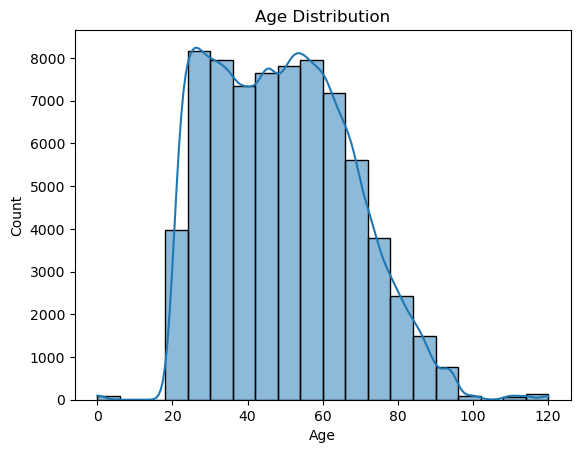

age_group
Middle-aged    49408
Young          13544
Senior          9429
Name: count, dtype: int64

In [23]:
#1.
df['age'].describe()
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 70, 150],
    labels=['Young', 'Middle-aged', 'Senior']
)
df['age_group'].value_counts()

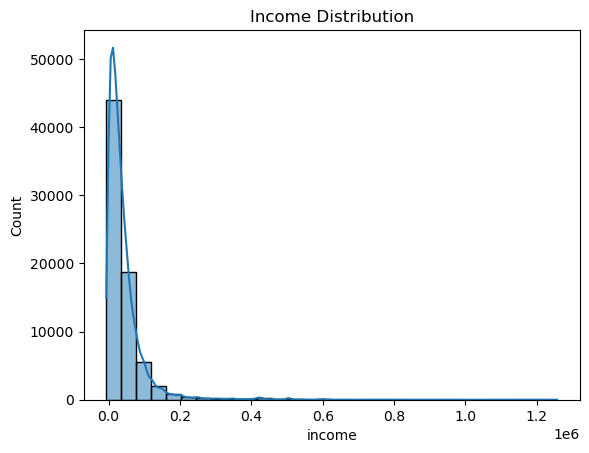

-6900.0
45


In [25]:
#2
sns.histplot(df['income'], bins=30, kde=True)
plt.title('Income Distribution')
plt.show()
print(df['income'].min())
print((df['income'] < 0).sum())

In [ ]:
#3
df['state_of_res'].value_counts().head(5)


In [ ]:
neg = df[df['income'] < 0]['income']
sns.histplot(neg, bins=30)
plt.title('Negative incomes')
plt.show()

In [7]:
df.isnull().sum()
df=df.rename(columns={'Unnamed: 0': 'idx'})

### We created 'niw' column with None values of is_employed column.

In [8]:
df['niw']=df['is_employed'].isna().astype(int) #New column with NaN values of is_employed
df['is_employed']=df['is_employed']==True #Replace NaN values to False values
df['sex']=(df['sex']=='Male').astype(int) #Replace False to 0 and True to 1 
df.head()

,idx,custid,sex,is_employed,income,marital_status,health_ins,housing_type,num_vehicles,age,state_of_res,code_column,gas_usage,rooms,recent_move_b,age_group,niw
0,7,000006646_03,1,True,22000.0,Never married,True,Homeowner free and clear,0.0,24,Alabama,1047,210.0,3,F,Young,0
1,8,000007827_01,0,False,23200.0,Divorced/Separated,True,Rented,0.0,82,Alabama,1047,3.0,6,T,Senior,1
2,9,000008359_04,0,True,21000.0,Never married,True,Homeowner with mortgage/loan,2.0,31,Alabama,1047,40.0,3,F,Middle-aged,0
3,10,000008529_01,0,False,37770.0,Widowed,True,Homeowner free and clear,1.0,93,Alabama,1047,120.0,2,F,Senior,1
4,11,000008744_02,1,True,39000.0,Divorced/Separated,True,Rented,2.0,67,Alabama,1047,3.0,2,F,Middle-aged,0


In [9]:
df['is_employed'] = df['is_employed'].astype(int)
df['health_ins'] = df['health_ins'].astype(int)
moda = df['recent_move_b'].mode()[0]
df['recent_move_b']=df['recent_move_b'].fillna( moda )
df['recent_move_b']=df['recent_move_b'].replace('F',0 )
df['recent_move_b']=df['recent_move_b'].replace('T',1 )

C:\Users\pufle\AppData\Local\Temp\ipykernel_34624\3494346374.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['recent_move_b']=df['recent_move_b'].replace('T',1 )


In [10]:
df.head()

,idx,custid,sex,is_employed,income,marital_status,health_ins,housing_type,num_vehicles,age,state_of_res,code_column,gas_usage,rooms,recent_move_b,age_group,niw
0,7,000006646_03,1,1,22000.0,Never married,1,Homeowner free and clear,0.0,24,Alabama,1047,210.0,3,0,Young,0
1,8,000007827_01,0,0,23200.0,Divorced/Separated,1,Rented,0.0,82,Alabama,1047,3.0,6,1,Senior,1
2,9,000008359_04,0,1,21000.0,Never married,1,Homeowner with mortgage/loan,2.0,31,Alabama,1047,40.0,3,0,Middle-aged,0
3,10,000008529_01,0,0,37770.0,Widowed,1,Homeowner free and clear,1.0,93,Alabama,1047,120.0,2,0,Senior,1
4,11,000008744_02,1,1,39000.0,Divorced/Separated,1,Rented,2.0,67,Alabama,1047,3.0,2,0,Middle-aged,0


In [11]:
df = pd.get_dummies(df, columns=['housing_type','marital_status'], dtype=int)

In [12]:
mediana = df['num_vehicles'].median()
df['num_vehicles']=df['num_vehicles'].fillna(mediana)
log_income =  np.sign(df['income']) * np.log1p(np.abs(df['income']))
df['income_norm'] = ((log_income - log_income.min()) / (log_income.max() - log_income.min()))


In [13]:
df=df.drop(columns=['state_of_res'])
df.head()

,idx,custid,sex,is_employed,income,health_ins,num_vehicles,age,code_column,gas_usage,...,niw,housing_type_Homeowner free and clear,housing_type_Homeowner with mortgage/loan,housing_type_Occupied with no rent,housing_type_Rented,marital_status_Divorced/Separated,marital_status_Married,marital_status_Never married,marital_status_Widowed,income_norm
0,7,000006646_03,1,1,22000.0,1,0.0,24,1047,210.0,...,0,1,0,0,0,0,0,1,0,0.823219
1,8,000007827_01,0,0,23200.0,1,0.0,82,1047,3.0,...,1,0,0,0,1,1,0,0,0,0.825540
2,9,000008359_04,0,1,21000.0,1,2.0,31,1047,40.0,...,0,0,1,0,0,0,0,1,0,0.821186
3,10,000008529_01,0,0,37770.0,1,1.0,93,1047,120.0,...,1,1,0,0,0,0,0,0,1,0.846836
4,11,000008744_02,1,1,39000.0,1,2.0,67,1047,3.0,...,0,0,0,0,1,1,0,0,0,0.848237


In [14]:
df['age_norm'] = (

    (df['age'] - df['age'].min()) /
    (df['age'].max() - df['age'].min())
)

df['gas_usage']=df['gas_usage'].fillna(0)
df['gas_usage_norm'] = (

    (df['gas_usage'] - df['gas_usage'].min()) /
    (df['gas_usage'].max() - df['gas_usage'].min())
)
df['num_vehicles']=df['num_vehicles'].astype(int)


In [15]:
df=df.drop(columns=['age','gas_usage','custid','income','age_group'])
df.head()

,idx,sex,is_employed,health_ins,num_vehicles,code_column,rooms,recent_move_b,niw,housing_type_Homeowner free and clear,housing_type_Homeowner with mortgage/loan,housing_type_Occupied with no rent,housing_type_Rented,marital_status_Divorced/Separated,marital_status_Married,marital_status_Never married,marital_status_Widowed,income_norm,age_norm,gas_usage_norm
0,7,1,1,1,0,1047,3,0,0,1,0,0,0,0,0,1,0,0.823219,0.200000,0.368421
1,8,0,0,1,0,1047,6,1,1,0,0,0,1,1,0,0,0,0.825540,0.683333,0.005263
2,9,0,1,1,2,1047,3,0,0,0,1,0,0,0,0,1,0,0.821186,0.258333,0.070175
3,10,0,0,1,1,1047,2,0,1,1,0,0,0,0,0,0,1,0.846836,0.775000,0.210526
4,11,1,1,1,2,1047,2,0,0,0,0,0,1,1,0,0,0,0.848237,0.558333,0.005263


<Axes: >

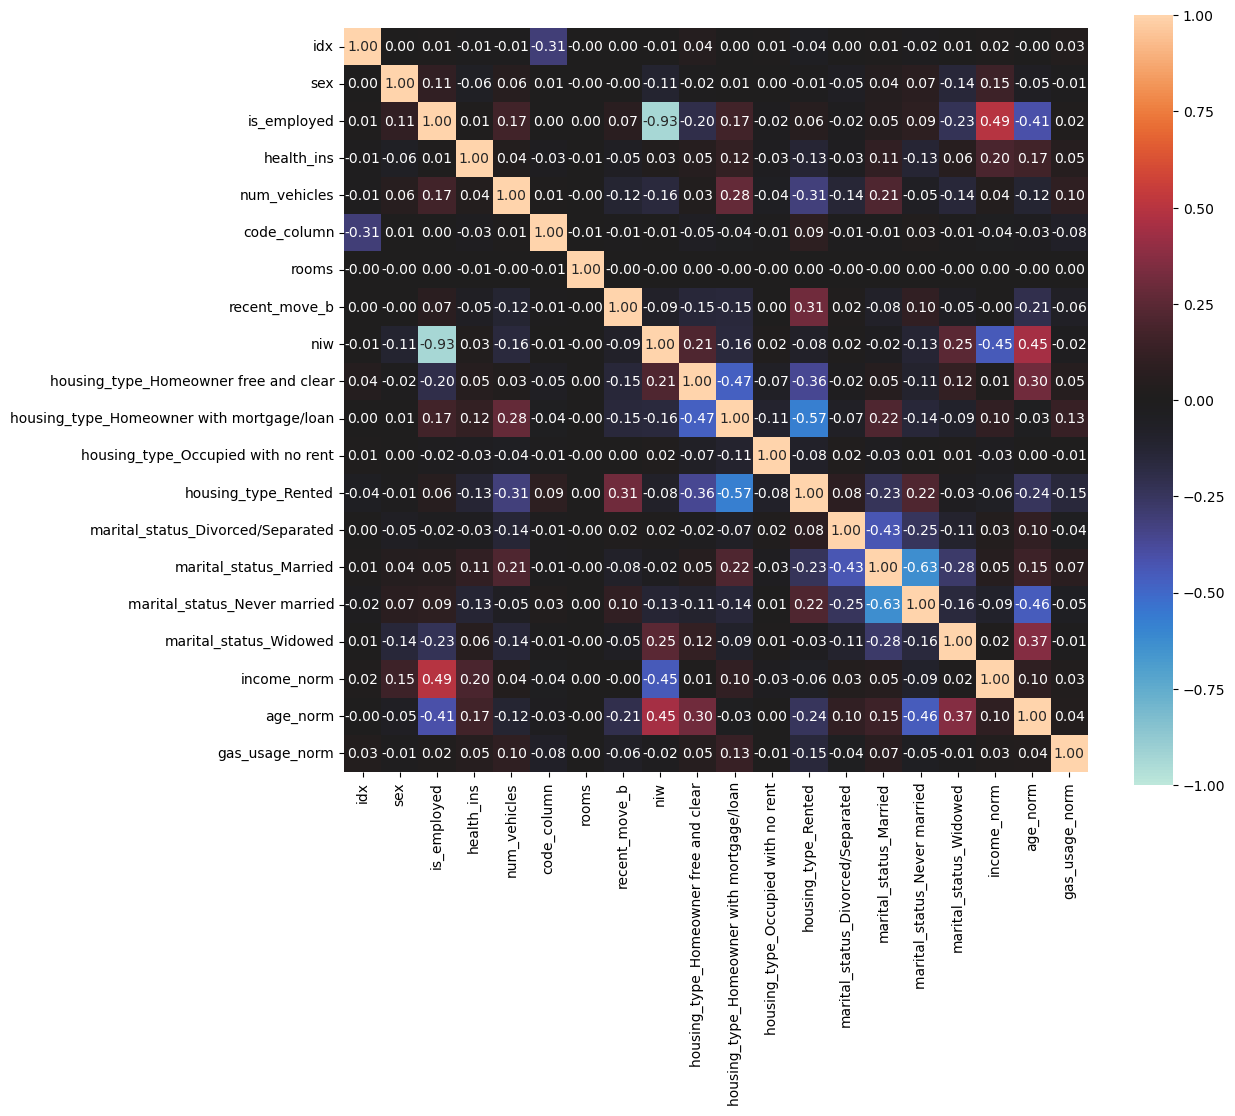

In [ ]:
corr = df.corr()
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)